In [1]:

import jax
import jax.numpy as jnp
from flax import nnx

from probjax.nn.nets.flows import AdditiveCouplingFlow

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
p = AdditiveCouplingFlow(4, 5, nnx.Rngs(1))

params = nnx.state(p, nnx.Param)

In [3]:
x1 = jax.random.normal(jax.random.PRNGKey(0), (1000, 4)) -2
x2 = jax.random.normal(jax.random.PRNGKey(1), (1000, 4)) +2

xs = jnp.concatenate([x1, x2], axis=0)

In [4]:
def loss(params):
    nnx.update(p, params)
    return -jnp.mean(p.log_prob(xs))

In [5]:
import optax

optimizer = optax.adam(1e-3)

@jax.jit
def update(params, opt_state):
    loss_val, grads = jax.value_and_grad(loss)(params)
    updates, opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return loss_val, new_params, opt_state

In [6]:
opt_state = optimizer.init(params)

In [7]:
for i in range(1000):
    loss_val, params, opt_state = update(params, opt_state)
    print(loss_val)

12.173242
11.042022
10.263108
9.743939
9.428938
9.249454
9.125543
9.008719
8.889691
8.781739
8.692993
8.62374
8.565957
8.51162
8.454882
8.394773
8.332234
8.267848
8.202063
8.134866
8.066307
7.9975424
7.930972
7.868612
7.8124027
7.761826
7.716653
7.6755123
7.6381598
7.6032443
7.571301
7.5416646
7.5142803
7.4887795
7.4648175
7.4414225
7.4185843
7.3960376
7.3737884
7.3520436
7.330583
7.3096046
7.2893887
7.270162
7.251936
7.2351265
7.2198625
7.2063446
7.194102
7.182694
7.171551
7.160403
7.1491585
7.137819
7.1266284
7.1155605
7.104713
7.094112
7.0838675
7.073722
7.063781
7.054007
7.0443244
7.034967
7.025802
7.0171237
7.0087123
7.000558
6.9926305
6.9847336
6.9770265
6.9693356
6.961723
6.9543
6.946971
6.9399457
6.9330482
6.926392
6.919914
6.9134994
6.9071236
6.9010043
6.894887
6.889051
6.8831887
6.8775306
6.8720813
6.8666973
6.8614845
6.85635
6.8513217
6.8463726
6.8414636
6.8366613
6.832002
6.827475
6.8229475
6.8185687
6.8142924
6.8100815
6.805906
6.801776
6.79781
6.7938323
6.7899756
6.786202

In [8]:
nnx.update(p, params)

In [9]:
samples = p.sample(jax.random.PRNGKey(0), (1000, ))

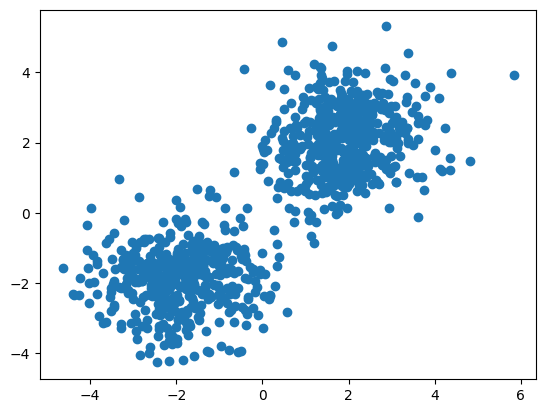

In [10]:
import matplotlib.pyplot as plt

plt.scatter(samples[:, 0], samples[:, 1])